# SAAM Project 2026

## Group N: Emerging Markets / Scope 1

---

## Project Overview

This notebook presents the implementation of the SAAM 2026 project for Group N (Emerging Markets / Scope 1).

The project is divided into two parts:

- Part I focuses on standard portfolio allocation using a long-only minimum variance strategy and a value-weighted benchmark.
- Part II extends the analysis by introducing carbon reduction and net-zero portfolio constraints.

The notebook follows the project instructions by:
- cleaning and preparing the raw financial and carbon datasets,
- constructing monthly stock returns,
- defining a dynamic investment universe,
- estimating portfolio weights using rolling historical windows,
- backtesting the portfolios out-of-sample,
- and comparing portfolio performance and carbon metrics.

---

# Preliminary Setup

## Environment Setup and Data Loading

This section loads the required Python libraries, defines the project structure, and imports the raw datasets used throughout the notebook.

The setup is designed to ensure that the analysis remains fully reproducible from the original project files.

### Required Libraries

In [1]:
from pathlib import Path
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Project Structure and Paths

In [2]:
# Automatically detect the project root directory
BASE_DIR = Path.cwd().resolve()

while not (BASE_DIR / "data_raw").exists():
    if BASE_DIR.parent == BASE_DIR:
        raise FileNotFoundError("Could not find project root containing data_raw/")
    BASE_DIR = BASE_DIR.parent

os.chdir(BASE_DIR)

# Main project folders
DATA_RAW = BASE_DIR / "data_raw"
DATA_PROCESSED = BASE_DIR / "data_processed"
OUTPUTS = BASE_DIR / "outputs"

# Output subfolders
TABLES_DIR = OUTPUTS / "tables"
FIGURES_DIR = OUTPUTS / "figures"
INTERMEDIATE_DIR = OUTPUTS / "intermediate"

# Make src/ importable throughout the notebook
SRC_DIR = BASE_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Create folders if they do not already exist
DATA_PROCESSED.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
INTERMEDIATE_DIR.mkdir(exist_ok=True)

# Basic project structure checks
assert DATA_RAW.exists(), "data_raw folder not found"
assert SRC_DIR.exists(), "src folder not found"
assert OUTPUTS.exists(), "outputs folder not found"

### Importing Project Functions

The main portfolio construction, backtesting, and reporting procedures are implemented in modular Python scripts located in the `src` folder.

Importing these functions keeps the notebook organized and ensures consistency with the full project pipeline.

In [3]:
# Import project-specific functions from src/

from src.cleaning import (
    prepare_price_data,
    prepare_market_caps_data,
    prepare_carbon_data,
    apply_low_price_filter,
    compute_returns,
    apply_delisting_returns,
)

from src.universe import (
    build_universe_by_year,
)

from src.optimization import (
    compute_mv_weights_by_year,
)

from src.backtest import (
    run_mv_backtest,
)

from src.benchmark import (
    run_vw_backtest,
)

from src.reporting import (
    prepare_risk_free_rate,
    build_performance_table,
    compute_cumulative_series,
    export_part1_outputs,
)

### Display configuration

In [4]:
# Configure pandas display settings for notebook readability

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", "{:.4f}".format)

### Global Project Parameters

The following parameters define the main assumptions used throughout the portfolio construction and backtesting process.

In [5]:
# Global project parameters
REGION = "EM"
CARBON_SCOPE = "SCOPE_1"

# Project timeline
START_ESTIMATION_YEAR = 2013
END_REBALANCE_YEAR = 2024
BACKTEST_START_YEAR = 2014
BACKTEST_END_YEAR = 2025

# Estimation and filtering rules
ROLLING_WINDOW_MONTHS = 120
MIN_HISTORY_MONTHS = 36
STALE_RETURN_THRESHOLD = 0.50
LOW_PRICE_THRESHOLD = 0.5

# Portfolio assumptions
INITIAL_WEALTH = 1_000_000
CARBON_REDUCTION_TARGET = 0.50
NET_ZERO_REDUCTION = 0.10

## Data Loading

This section loads the raw datasets used throughout the project.

At this stage, the files are imported and briefly inspected before the data cleaning and portfolio construction steps.

### Loading the Raw Datasets

The following datasets are loaded from the project folder:

- static firm information,
- monthly total return index data,
- monthly market capitalization data,
- and annual carbon emissions data.

Although the carbon objective is introduced in Part II, carbon data is already required in Part I because firms without available emissions data are excluded from the investment universe at each rebalancing date.

In [6]:
# Load the main datasets used throughout the project

static = pd.read_excel(DATA_RAW / "Static_2025.xlsx")
prices_raw = pd.read_excel(DATA_RAW / "DS_RI_T_USD_M_2025.xlsx")
market_caps_raw = pd.read_excel(DATA_RAW / "DS_MV_T_USD_M_2025.xlsx")
carbon_raw = pd.read_excel(DATA_RAW / "DS_CO2_SCOPE_1_Y_2025.xlsx")

### Inspecting the Raw Datasets

Before starting the cleaning process, the raw datasets are briefly inspected to verify their structure and consistency.

In [7]:
# Inspect dataset dimensions

print("Static shape:", static.shape)
print("Prices raw shape:", prices_raw.shape)
print("Market caps raw shape:", market_caps_raw.shape)
print("Carbon raw shape:", carbon_raw.shape)

Static shape: (2545, 4)
Prices raw shape: (2609, 316)
Market caps raw shape: (2609, 316)
Carbon raw shape: (2609, 29)


In [8]:
# Preview static firm information
static.head()

,ISIN,NAME,Country,Region
0,AN8068571086,SLB,US,AMER
1,ARALUA010258,ALUAR,AR,EM
2,ARP125991090,BANCO BBVA ARGENTINA,AR,EM
3,ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM
4,AT000000STR1,STRABAG SE,AT,EUR


In [9]:
# Preview raw monthly return index data
prices_raw.head()

,NAME,ISIN,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,2000-10-31 00:00:00,2000-11-30 00:00:00,2000-12-29 00:00:00,2001-01-31 00:00:00,2001-02-28 00:00:00,2001-03-30 00:00:00,2001-04-30 00:00:00,2001-05-31 00:00:00,2001-06-29 00:00:00,2001-07-31 00:00:00,2001-08-31 00:00:00,2001-09-28 00:00:00,2001-10-31 00:00:00,...,2024-01-31 00:00:00,2024-02-29 00:00:00,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00,2025-01-31 00:00:00,2025-02-28 00:00:00,2025-03-31 00:00:00,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
0,NaN,NaN,"$$ER: E100,INVALID CODE OR EXPRESSION ENTERED",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SLB,AN8068571086,1708.0100,1858.2600,2254.1500,2334.7500,2336.6500,2245.0900,2283.7000,2262.6700,2610.7700,2524.4300,2334.6700,1901.4700,2457.7200,2361.2600,1965.6800,1776.3600,2044.3100,1943.4800,1628.1100,1662.1300,1521.0400,1418.6000,1503.0400,...,4639.4600,4630.5800,5251.4400,4549.1400,4396.8000,4549.1700,4656.2000,4241.5900,4071.8100,3889.3300,4264.9600,3745.3500,3934.8700,4098.1000,4111.8700,3270.8100,3251.1300,3353.4200,3353.4200,3655.0300,3437.7400,3606.7700,3624.7800,3867.9600,4875.7700
2,ALUAR,ARALUA010258,1547.0400,1820.1100,1911.1200,1866.1100,1835.9300,1805.2200,1657.4200,1911.9500,1982.9900,1865.4200,1775.8200,1627.8400,1455.5200,1695.7300,1695.4400,1575.0100,1574.8400,1604.5600,1500.4700,1500.8900,1464.7400,1286.2400,1322.2500,...,6889.5000,5135.7000,5760.9600,5331.6500,6253.4300,5993.0000,5680.5300,5323.9400,4928.6600,4706.0500,5207.1800,4802.8900,4538.4900,4010.5000,4557.5400,3095.4000,3702.9600,3344.2300,3256.0900,3037.9300,2793.7700,3782.2900,4021.7200,3812.3300,4041.3100
3,BANCO BBVA ARGENTINA,ARP125991090,418.2300,396.5400,467.4900,418.3700,350.6600,352.5200,401.7500,404.4800,398.4700,380.0500,395.1900,352.5600,378.2400,565.7500,526.8500,471.8500,511.1600,512.1200,471.2500,277.1500,260.0400,168.0800,163.0000,...,360.1700,312.2100,412.7700,458.4200,672.8200,624.6400,569.6900,669.6600,637.8700,774.2600,885.6300,1067.8800,1213.2500,1031.3700,1070.5100,993.4800,952.8700,805.0600,775.5400,607.6700,452.8600,840.3300,834.2700,938.5300,1039.7500
4,TERNIUM ARGENTINA SOCIEDAD ANONIMA,ARSIDE010029,178.4000,177.5300,184.5500,184.1600,171.0500,112.6500,120.5500,124.9300,137.2100,128.9300,118.1100,104.7400,110.2400,142.1800,109.6300,112.7900,102.5300,100.7100,82.0000,65.5300,59.2700,49.9200,34.7700,...,1411.8100,1021.0800,1182.6700,1092.5200,1295.3700,1215.4800,1155.2700,999.7100,974.2600,916.6500,1076.9400,982.5500,917.5600,774.1100,866.6500,587.9400,663.2600,588.2700,590.4200,490.3900,476.3100,568.8600,630.9800,527.5200,552.8600


---
# Part I — Standard Portfolio Allocation

## Data Cleaning

This section prepares the raw datasets for the empirical analysis.

The main objective is to construct clean and consistent time-series datasets that can be used for portfolio construction and backtesting.

#### Filtering the Emerging Markets Universe

The project is assigned to the Emerging Markets region. The initial investment universe is therefore restricted to firms classified as Emerging Markets in the static reference dataset.

In [10]:
# Select firms belonging to the assigned region

em_firms = static[static["Region"] == REGION].copy()
em_isins = em_firms["ISIN"].tolist()

print("Number of firms in the Emerging Markets universe:", len(em_isins))

Number of firms in the Emerging Markets universe: 702


In [11]:
# Preview the selected regional universe

em_firms.head()

,ISIN,NAME,Country,Region
1,ARALUA010258,ALUAR,AR,EM
2,ARP125991090,BANCO BBVA ARGENTINA,AR,EM
3,ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM
117,BMG211591018,CHINA YURUN FOOD GROUP,CN,EM
144,BRABEVACNOR1,AMBEV ON,BR,EM


### Preparing Carbon Emissions Data

Carbon emissions are cleaned at this stage because carbon data availability is used later when defining the yearly investment universe. Missing annual values are carried forward using the most recent previously available observation, as required by the project instructions.

In [12]:
carbon_data = prepare_carbon_data(carbon_raw, em_isins)

print("Carbon dataset shape:", carbon_data.shape)
carbon_data.head()

Carbon dataset shape: (702, 27)


,1999-12-31,2000-12-31,2001-12-31,2002-12-31,2003-12-31,2004-12-31,2005-12-31,2006-12-31,2007-12-31,2008-12-31,2009-12-31,2010-12-31,2011-12-31,2012-12-31,2013-12-31,2014-12-31,2015-12-31,2016-12-31,2017-12-31,2018-12-31,2019-12-31,2020-12-31,2021-12-31,2022-12-31,2023-12-31,2024-12-31,2025-12-31
ISIN,,,,,,,,,,,,,,,,,,,,,,,,,,,
ARALUA010258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2414112.0000,2414112.0000
ARP125991090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9969.6700,8198.6700,7038.6500,7038.6500,7038.6500,442.6200,366.8600,1091.1300,1475.2000,1475.2000
ARSIDE010029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMG211591018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38468.0000,51886.0000,51515.0000,76154.0000,21477.0000,21301.0000,14980.0000,13173.0000,13173.0000
BRABEVACNOR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,356414.0000,351297.0000,274598.0000,457821.0000,668740.0000,581763.0000,576069.0900,484000.0000,483000.0000,483000.0000


### Removing Invalid Rows

Some Datastream exports contain invalid rows generated during the extraction process. Rows without valid ISIN identifiers are removed before constructing the cleaned datasets.

In [13]:
# Remove invalid extraction rows

prices_raw = prices_raw[prices_raw["ISIN"].notna()]
market_caps_raw = market_caps_raw[market_caps_raw["ISIN"].notna()]

In [14]:
# Inspect the price dataset after removing invalid rows

prices_raw.head()

,NAME,ISIN,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,2000-10-31 00:00:00,2000-11-30 00:00:00,2000-12-29 00:00:00,2001-01-31 00:00:00,2001-02-28 00:00:00,2001-03-30 00:00:00,2001-04-30 00:00:00,2001-05-31 00:00:00,2001-06-29 00:00:00,2001-07-31 00:00:00,2001-08-31 00:00:00,2001-09-28 00:00:00,2001-10-31 00:00:00,...,2024-01-31 00:00:00,2024-02-29 00:00:00,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00,2025-01-31 00:00:00,2025-02-28 00:00:00,2025-03-31 00:00:00,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
1,SLB,AN8068571086,1708.0100,1858.2600,2254.1500,2334.7500,2336.6500,2245.0900,2283.7000,2262.6700,2610.7700,2524.4300,2334.6700,1901.4700,2457.7200,2361.2600,1965.6800,1776.3600,2044.3100,1943.4800,1628.1100,1662.1300,1521.0400,1418.6000,1503.0400,...,4639.4600,4630.5800,5251.4400,4549.1400,4396.8000,4549.1700,4656.2000,4241.5900,4071.8100,3889.3300,4264.9600,3745.3500,3934.8700,4098.1000,4111.8700,3270.8100,3251.1300,3353.4200,3353.4200,3655.0300,3437.7400,3606.7700,3624.7800,3867.9600,4875.7700
2,ALUAR,ARALUA010258,1547.0400,1820.1100,1911.1200,1866.1100,1835.9300,1805.2200,1657.4200,1911.9500,1982.9900,1865.4200,1775.8200,1627.8400,1455.5200,1695.7300,1695.4400,1575.0100,1574.8400,1604.5600,1500.4700,1500.8900,1464.7400,1286.2400,1322.2500,...,6889.5000,5135.7000,5760.9600,5331.6500,6253.4300,5993.0000,5680.5300,5323.9400,4928.6600,4706.0500,5207.1800,4802.8900,4538.4900,4010.5000,4557.5400,3095.4000,3702.9600,3344.2300,3256.0900,3037.9300,2793.7700,3782.2900,4021.7200,3812.3300,4041.3100
3,BANCO BBVA ARGENTINA,ARP125991090,418.2300,396.5400,467.4900,418.3700,350.6600,352.5200,401.7500,404.4800,398.4700,380.0500,395.1900,352.5600,378.2400,565.7500,526.8500,471.8500,511.1600,512.1200,471.2500,277.1500,260.0400,168.0800,163.0000,...,360.1700,312.2100,412.7700,458.4200,672.8200,624.6400,569.6900,669.6600,637.8700,774.2600,885.6300,1067.8800,1213.2500,1031.3700,1070.5100,993.4800,952.8700,805.0600,775.5400,607.6700,452.8600,840.3300,834.2700,938.5300,1039.7500
4,TERNIUM ARGENTINA SOCIEDAD ANONIMA,ARSIDE010029,178.4000,177.5300,184.5500,184.1600,171.0500,112.6500,120.5500,124.9300,137.2100,128.9300,118.1100,104.7400,110.2400,142.1800,109.6300,112.7900,102.5300,100.7100,82.0000,65.5300,59.2700,49.9200,34.7700,...,1411.8100,1021.0800,1182.6700,1092.5200,1295.3700,1215.4800,1155.2700,999.7100,974.2600,916.6500,1076.9400,982.5500,917.5600,774.1100,866.6500,587.9400,663.2600,588.2700,590.4200,490.3900,476.3100,568.8600,630.9800,527.5200,552.8600
5,STRABAG SE,AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,176.2400,176.5900,195.7400,198.0000,204.5600,204.4100,205.0600,212.4700,204.9400,192.7100,199.6300,200.2800,240.2600,286.2000,349.6200,430.2700,430.8300,479.4600,477.3500,465.0600,461.5000,396.6500,452.8700,481.4900,526.8800


### Preparing Clean Price and Market Capitalization Matrices

The cleaning functions remove non-time-series columns and transform the raw Datastream exports into consistent asset-by-time matrices restricted to the Emerging Markets investment universe.

This step also corresponds to the final clean matrices previously prepared manually in the notebook.

In [15]:
# Prepare clean monthly price and market capitalization matrices

price_data = prepare_price_data(
    prices_raw,
    em_isins
)

market_caps_data = prepare_market_caps_data(
    market_caps_raw,
    em_isins
)

print("Price matrix shape:", price_data.shape)
print("Market capitalization matrix shape:", market_caps_data.shape)

Price matrix shape: (702, 314)
Market capitalization matrix shape: (702, 314)


In [16]:
# Preview the cleaned monthly price matrix

price_data.head()

,1999-12-31,2000-01-31,2000-02-29,2000-03-31,2000-04-28,2000-05-31,2000-06-30,2000-07-31,2000-08-31,2000-09-29,2000-10-31,2000-11-30,2000-12-29,2001-01-31,2001-02-28,2001-03-30,2001-04-30,2001-05-31,2001-06-29,2001-07-31,2001-08-31,2001-09-28,2001-10-31,2001-11-30,2001-12-31,...,2024-01-31,2024-02-29,2024-03-29,2024-04-30,2024-05-31,2024-06-28,2024-07-31,2024-08-30,2024-09-30,2024-10-31,2024-11-29,2024-12-31,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-30,2025-06-30,2025-07-31,2025-08-29,2025-09-30,2025-10-31,2025-11-28,2025-12-31,2026-01-30
ISIN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ARALUA010258,1547.0400,1820.1100,1911.1200,1866.1100,1835.9300,1805.2200,1657.4200,1911.9500,1982.9900,1865.4200,1775.8200,1627.8400,1455.5200,1695.7300,1695.4400,1575.0100,1574.8400,1604.5600,1500.4700,1500.8900,1464.7400,1286.2400,1322.2500,1324.8400,1429.9700,...,6889.5000,5135.7000,5760.9600,5331.6500,6253.4300,5993.0000,5680.5300,5323.9400,4928.6600,4706.0500,5207.1800,4802.8900,4538.4900,4010.5000,4557.5400,3095.4000,3702.9600,3344.2300,3256.0900,3037.9300,2793.7700,3782.2900,4021.7200,3812.3300,4041.3100
ARP125991090,418.2300,396.5400,467.4900,418.3700,350.6600,352.5200,401.7500,404.4800,398.4700,380.0500,395.1900,352.5600,378.2400,565.7500,526.8500,471.8500,511.1600,512.1200,471.2500,277.1500,260.0400,168.0800,163.0000,145.1300,167.4900,...,360.1700,312.2100,412.7700,458.4200,672.8200,624.6400,569.6900,669.6600,637.8700,774.2600,885.6300,1067.8800,1213.2500,1031.3700,1070.5100,993.4800,952.8700,805.0600,775.5400,607.6700,452.8600,840.3300,834.2700,938.5300,1039.7500
ARSIDE010029,178.4000,177.5300,184.5500,184.1600,171.0500,112.6500,120.5500,124.9300,137.2100,128.9300,118.1100,104.7400,110.2400,142.1800,109.6300,112.7900,102.5300,100.7100,82.0000,65.5300,59.2700,49.9200,34.7700,33.0100,48.1300,...,1411.8100,1021.0800,1182.6700,1092.5200,1295.3700,1215.4800,1155.2700,999.7100,974.2600,916.6500,1076.9400,982.5500,917.5600,774.1100,866.6500,587.9400,663.2600,588.2700,590.4200,490.3900,476.3100,568.8600,630.9800,527.5200,552.8600
BMG211591018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.6700,0.6600,0.6300,0.5900,0.5900,0.5600,0.5100,0.5900,0.6200,0.8000,0.6700,0.6300,0.5600,0.5600,0.5600,0.6000,0.5200,0.5200,0.6000,0.5700,0.5400,0.5000,0.4900,0.4000,0.4600
BRABEVACNOR1,61.8000,59.0700,56.3800,74.0800,73.9800,70.8200,89.5800,110.7400,110.0500,119.7800,141.0300,140.0800,172.5400,188.5200,171.6500,161.8700,170.5200,154.6600,159.9400,144.5000,127.9900,97.1600,104.5600,115.3600,133.5200,...,1272.8500,1217.4000,1199.7800,1127.1400,1057.5700,987.7300,985.0100,1091.8500,1154.8900,1049.9200,1025.1800,963.6200,963.5500,1055.8900,1206.4100,1317.2700,1263.9500,1260.2800,1149.2800,1187.0900,1184.4800,1231.4500,1353.4100,1392.2400,1561.2700


---
## Construction of Monthly Returns

### Filtering Unrealistic Prices

Very low price observations may correspond to illiquid securities, penny stocks, or Datastream extraction issues. Following the project guidelines, prices below 0.5 USD are treated as missing values before computing returns.

In [17]:
# Apply the Datastream low-price filter

price_data = apply_low_price_filter(
    price_data,
    LOW_PRICE_THRESHOLD
)

### Computing Monthly Returns

Monthly returns are computed from the Datastream return index series using simple percentage changes between consecutive monthly observations.

Following the project instructions, firms that disappear permanently from the dataset are treated as delisting events. When a last valid price observation is followed only by missing values, the first missing month is assigned a return of −100%.

In [18]:
# Compute monthly returns and apply delisting return adjustments

returns = compute_returns(price_data)
returns = apply_delisting_returns(price_data, returns)

In [19]:
# Inspect extreme return observations

stacked_returns = returns.stack()

print("Minimum return:", stacked_returns.min())
print("Maximum return:", stacked_returns.max())

print("\nFive most negative returns:")
print(stacked_returns.nsmallest(5))

print("\nFive most positive returns:")
print(stacked_returns.nlargest(5))

Minimum return: -1.0
Maximum return: 9.419463087248323

Five most negative returns:
ISIN                    
BMG211591018  2025-11-28   -1.0000
BRBRFSACNOR8  2025-09-30   -1.0000
BRCESPACNPB4  2022-03-31   -1.0000
BRCPLEACNPB9  2025-11-28   -1.0000
BRGFSAACNOR3  2022-04-29   -1.0000
dtype: float64

Five most positive returns:
ISIN                    
TW0003376000  2005-12-30   9.4195
EGS673T1C012  2007-07-31   7.1042
GRS314003013  2023-02-28   3.1153
CL0000000423  2022-09-30   2.9167
INE686F01025  2004-11-30   1.9846
dtype: float64


The distribution of monthly returns was inspected for potential data anomalies. Although a small number of extremely large positive returns were observed, these observations correspond mainly to firms with very small market capitalizations and therefore have limited impact on the value-weighted benchmark. Consistent with the project instructions, returns were not winsorized.

In [20]:
# Summarize the distribution of cleaned monthly returns

returns.stack().describe()

count   185798.0000
mean         0.0138
std          0.1266
min         -1.0000
25%         -0.0518
50%          0.0069
75%          0.0709
max          9.4195
dtype: float64

In [21]:
# Final return matrix used for portfolio construction

returns_matrix = returns.copy()

# Preview the return matrix
returns_matrix.iloc[:5, :5]

,1999-12-31,2000-01-31,2000-02-29,2000-03-31,2000-04-28
ISIN,,,,,
ARALUA010258,NaN,0.1765,0.0500,-0.0236,-0.0162
ARP125991090,NaN,-0.0519,0.1789,-0.1051,-0.1618
ARSIDE010029,NaN,-0.0049,0.0395,-0.0021,-0.0712
BMG211591018,NaN,NaN,NaN,NaN,NaN
BRABEVACNOR1,NaN,-0.0442,-0.0455,0.3139,-0.0013


---
## Minimum-Variance Portfolio Allocation

## 2.1 Investment Set

The investment universe is redefined each year based on data availability and screening criteria. This dynamic approach ensures that portfolio optimization is performed only on firms with sufficiently reliable return histories and available market information.

#### Firm Eligibility Rules

A firm is considered eligible if it satisfies minimum data availability and liquidity requirements within the estimation window. These filters help exclude firms with insufficient historical information or limited trading activity.

In [22]:
# Define yearly investment universes using the eligibility rules

rebalance_years = list(range(2014, 2026))

universe_by_year = build_universe_by_year(
    returns_matrix=returns_matrix,
    price_data=price_data,
    carbon_data=carbon_data,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
    min_history_months=MIN_HISTORY_MONTHS,
    stale_return_threshold=STALE_RETURN_THRESHOLD,
)

#### Constructing the Yearly Investment Universe

For each rebalancing year, the eligible investment universe is constructed using only information available at the end of the previous year. Eligibility is assessed firm by firm according to the screening rules defined above.

#### Inspecting the Dynamic Universe

The size of the eligible investment universe changes over time as firms enter or leave the sample depending on data availability and screening constraints.

In [23]:
# Number of eligible firms by rebalancing year

for year in rebalance_years:
    print(f"{year}: {len(universe_by_year[year])} firms")

2014: 254 firms
2015: 278 firms
2016: 309 firms
2017: 345 firms
2018: 389 firms
2019: 424 firms
2020: 472 firms
2021: 511 firms
2022: 546 firms
2023: 573 firms
2024: 584 firms
2025: 568 firms


#### Shared Covariance Inputs

To avoid recomputing the same rolling covariance matrices, we precompute them once for each rebalancing year and reuse them in the minimum-variance optimization.

In [24]:
# Precompute rolling covariance matrices for Part I

covariance_by_year = {}

for year in rebalance_years:
    universe = universe_by_year[year]
    end_prev = pd.Timestamp(f"{year - 1}-12-31")

    window = returns_matrix.loc[universe, :end_prev].iloc[:, -ROLLING_WINDOW_MONTHS:]
    covariance_by_year[year] = window.T.cov()

print("Part I yearly covariance matrices precomputed.")

Part I yearly covariance matrices precomputed.


## 2.2 Minimum Variance Portfolio

This section constructs the long-only minimum variance portfolio.

For each rebalancing year, the covariance matrix of asset returns is estimated using the previous 120 monthly observations. Portfolio weights are then obtained by solving a constrained quadratic optimization problem under full-investment and long-only constraints.

#### Defining the Optimization Problem

The long-only minimum variance portfolio is obtained by minimizing portfolio variance subject to two constraints:

- portfolio weights must sum to one,
- short-selling is not allowed.

The corresponding optimization routine is implemented in `src.optimization` and applied below to estimate yearly portfolio weights.

#### Computing Yearly Minimum Variance Weights

For each rebalancing year, the covariance matrix is estimated using the firms belonging to the corresponding dynamic investment universe. The optimization problem is then solved separately each year to obtain yearly portfolio weights.

In [25]:
# Compute yearly minimum variance portfolio weights

mv_weights_by_year = compute_mv_weights_by_year(
    returns_matrix=returns_matrix,
    universe_by_year=universe_by_year,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
    covariance_by_year=covariance_by_year,
)

[optimization] 2014: computing minimum-variance weights for 254 assets...
[optimization] 2014: done.
[optimization] 2015: computing minimum-variance weights for 278 assets...
[optimization] 2015: done.
[optimization] 2016: computing minimum-variance weights for 309 assets...
[optimization] 2016: done.
[optimization] 2017: computing minimum-variance weights for 345 assets...
[optimization] 2017: done.
[optimization] 2018: computing minimum-variance weights for 389 assets...
[optimization] 2018: done.
[optimization] 2019: computing minimum-variance weights for 424 assets...
[optimization] 2019: done.
[optimization] 2020: computing minimum-variance weights for 472 assets...
[optimization] 2020: done.
[optimization] 2021: computing minimum-variance weights for 511 assets...
[optimization] 2021: done.
[optimization] 2022: computing minimum-variance weights for 546 assets...
[optimization] 2022: done.
[optimization] 2023: computing minimum-variance weights for 573 assets...
[optimization] 20

In [26]:
# Inspect the first yearly minimum variance portfolio

print("Sum of weights in 2014:", mv_weights_by_year[2014].sum())

mv_weights_by_year[2014].head()

Sum of weights in 2014: 1.0


ISIN
BRBBASACNOR3   0.0000
BRBBDCACNPR8   0.0000
BRBRFSACNOR8   0.0000
BRBRKMACNPA4   0.0000
BRCESPACNPB4   0.0000
dtype: float64

### Backtesting the Minimum Variance Portfolio

This section evaluates the out-of-sample performance of the minimum variance portfolio.

For each rebalancing year, the portfolio weights estimated at the end of the previous year are applied to the realized monthly returns of the corresponding year. The backtesting procedure is implemented in `src.backtest` and applied below.

#### Running the Yearly Backtest

The yearly backtest is performed by combining the estimated minimum variance weights with the realized monthly returns of the corresponding year.

The resulting yearly return series are then concatenated into a single out-of-sample series covering the 2014–2025 period.

In [27]:
# Run the yearly minimum variance backtest

mv_returns_by_year, mv_returns_oos = run_mv_backtest(
    returns_matrix=returns_matrix,
    mv_weights_by_year=mv_weights_by_year,
    rebalance_years=rebalance_years,
)

In [28]:
# Total cumulative return of the minimum variance strategy

mv_total_cum_return = (1 + mv_returns_oos).prod() - 1

print("Minimum Variance total cumulative return:", mv_total_cum_return)

Minimum Variance total cumulative return: 1.3956355033756265


## 2.3 Comparison with the Value-Weighted Portfolio

This section constructs the value-weighted benchmark portfolio used for comparison with the minimum variance strategy.

The benchmark is built using the same dynamic investment universe. Monthly portfolio weights are computed from lagged market capitalizations in order to avoid look-ahead bias.

#### Computing the Value-Weighted Benchmark

The value-weighted benchmark is constructed using the same dynamic investment universe as the minimum variance strategy.

For each month, portfolio weights are based on lagged market capitalizations observed at the end of the previous month. The benchmark backtesting procedure is implemented in `src.benchmark` and applied below.

#### Backtesting the Value-Weighted Benchmark

The out-of-sample benchmark return series is constructed year by year using the same dynamic investment universe as the minimum variance strategy. Monthly benchmark returns are computed using lagged market capitalization weights.

In [29]:
# Run the yearly value-weighted benchmark backtest

vw_returns_by_year, vw_returns_oos = run_vw_backtest(
    returns_matrix=returns_matrix,
    market_caps_data=market_caps_data,
    universe_by_year=universe_by_year,
    rebalance_years=rebalance_years,
)

In [30]:
# Total cumulative return of the value-weighted benchmark

vw_total_cum_return = (1 + vw_returns_oos).prod() - 1

print("Value-weighted total cumulative return:", vw_total_cum_return)

Value-weighted total cumulative return: 1.2918006638928738


#### Performance Statistics

Performance statistics are computed from the monthly out-of-sample return series over the 2014–2025 period.

In [31]:
# Build Part I performance summary table

risk_free_raw = pd.read_excel(DATA_RAW / "Risk_Free_Rate_2025.xlsx")
risk_free_rate = prepare_risk_free_rate(risk_free_raw)

performance = build_performance_table(
    mv_returns_oos=mv_returns_oos,
    vw_returns_oos=vw_returns_oos,
    risk_free_rate=risk_free_rate,
)

performance

,Portfolio,Annualized Return,Annualized Volatility,Sharpe Ratio,Minimum Monthly Return,Maximum Monthly Return,Total Cumulative Return
0,Minimum Variance,0.0788,0.1081,0.5670,-0.0747,0.1367,1.3956
1,Value Weighted,0.0816,0.1568,0.4088,-0.1676,0.1344,1.2918


#### Cumulative Return Comparison

To visualize the evolution of portfolio performance over time, cumulative wealth indices are computed from the monthly return series of both strategies.

In [32]:
# Compute cumulative wealth indices for both strategies

mv_cumulative, vw_cumulative = compute_cumulative_series(
    mv_returns_oos=mv_returns_oos,
    vw_returns_oos=vw_returns_oos,
)

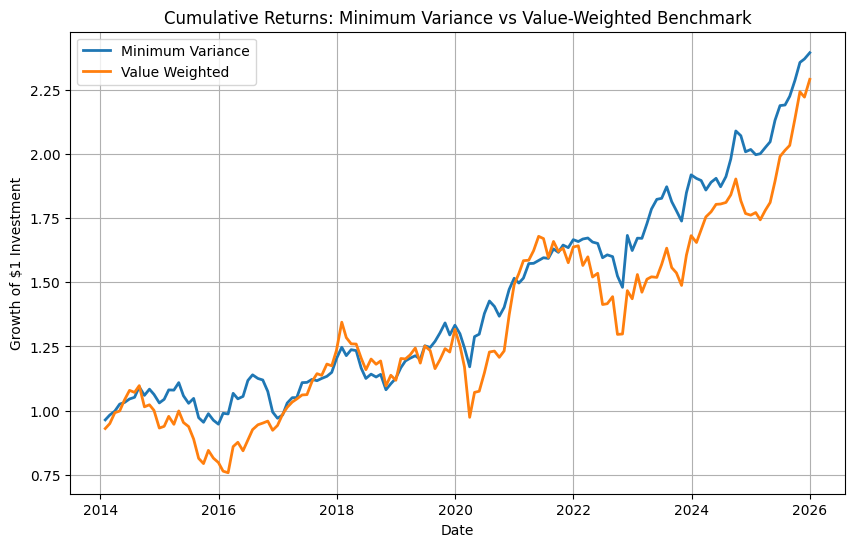

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(mv_cumulative, label="Minimum Variance", linewidth=2)
plt.plot(vw_cumulative, label="Value Weighted", linewidth=2)

plt.title("Cumulative Returns: Minimum Variance vs Value-Weighted Benchmark")
plt.ylabel("Growth of $1 Investment")
plt.xlabel("Date")

plt.legend()
plt.grid()

plt.savefig(
    FIGURES_DIR / "cumulative_portfolio_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.4 Part I Summary

In Part I, we constructed and evaluated a long-only minimum variance portfolio using the Emerging Markets universe assigned to our group.

After cleaning the Datastream data and constructing monthly return series, we defined a dynamic investment universe based on data availability and eligibility constraints. Portfolio weights were estimated using rolling covariance matrices and evaluated through an out-of-sample backtest over the 2014–2025 period.

The minimum variance portfolio was then compared with a value-weighted benchmark using standard performance metrics and cumulative return analysis.

Part II extends this framework by incorporating carbon-related portfolio constraints.

## 2.5 Saving Part I Results

In [34]:
# Export Part I output tables

exported_paths = export_part1_outputs(
    mv_returns_oos=mv_returns_oos,
    vw_returns_oos=vw_returns_oos,
    performance=performance,
    tables_dir=TABLES_DIR,
)

print("Part I outputs successfully saved.")

Part I outputs successfully saved.


In [35]:
# Export results to the Part I Excel template

template_path = BASE_DIR / "Template for Part I-SAAM.xlsx"
output_template = OUTPUTS / "Part_I_results_filled.xlsx"

with pd.ExcelWriter(output_template, engine="openpyxl", mode="w") as writer:

    # Portfolio performance summary
    performance.to_excel(
        writer,
        sheet_name="Portfolio Performance",
        index=False
    )

    # Monthly returns
    returns_table = pd.DataFrame({
        "Date": mv_returns_oos.index,
        "Minimum Variance": mv_returns_oos.values,
        "Value Weighted": vw_returns_oos.values
    })

    returns_table.to_excel(
        writer,
        sheet_name="Monthly Returns",
        index=False
    )

print("Excel template successfully exported.")

Excel template successfully exported.


---

# Part II - Portfolio Allocation with Carbon Emission Reduction

**Group N | Region: Emerging Markets | Scope: CO2 Scope 1**

This part follows the structure of the project brief. It builds on the Part I minimum-variance and value-weighted portfolios, then studies how portfolio allocation changes once carbon objectives are introduced.

## Preparatory Setup for Part II

Before implementing the carbon allocation exercises, we reload the project configuration and make the flattened project structure available to Python.

In [36]:
from src.config import (
    REGION, ROLLING_WINDOW_MONTHS, MIN_HISTORY_MONTHS,
    STALE_RETURN_THRESHOLD, LOW_PRICE_THRESHOLD,
    INITIAL_WEALTH, CARBON_REDUCTION_TARGET,
    NET_ZERO_REDUCTION, NET_ZERO_BASE_YEAR,
)
from src.paths import get_part2_paths, ensure_part2_directories

paths = get_part2_paths()
ensure_part2_directories(paths)

print(f'Region: {REGION}')
print(f'Carbon reduction target: {CARBON_REDUCTION_TARGET*100:.0f}%')
print(f'Net-zero annual reduction: {NET_ZERO_REDUCTION*100:.0f}%/yr')

Region: EM
Carbon reduction target: 50%
Net-zero annual reduction: 10%/yr


### Data and Carbon Inputs

We reuse the cleaned financial data from Part I and add the annual carbon emissions, revenues, and market capitalization variables needed to compute carbon intensity, WACI, and carbon footprint.

In [37]:
# Load raw financial and carbon datasets
from src.loaders import load_raw_datasets
from src.cleaning import (
    prepare_price_data, prepare_market_caps_data, prepare_carbon_data,
    apply_low_price_filter, compute_returns, apply_delisting_returns,
)
from src.carbon import prepare_revenue_data, prepare_annual_market_caps


static, prices_raw, market_caps_raw, carbon_scope1_raw = load_raw_datasets(paths['DATA_RAW'])
revenue_raw     = pd.read_excel(paths['DATA_RAW'] / 'DS_REV_Y_2025.xlsx')
annual_caps_raw = pd.read_excel(paths['DATA_RAW'] / 'DS_MV_T_USD_Y_2025.xlsx')

em_firms = static[static['Region'] == REGION].copy()
em_isins = em_firms['ISIN'].tolist()
print(f'EM universe: {len(em_isins)} ISINs in static file')

price_data       = apply_low_price_filter(prepare_price_data(prices_raw, em_isins), LOW_PRICE_THRESHOLD)
market_caps_data = prepare_market_caps_data(market_caps_raw, em_isins)
carbon_data      = prepare_carbon_data(carbon_scope1_raw, em_isins)
revenue_data     = prepare_revenue_data(revenue_raw, em_isins)
annual_caps_data = prepare_annual_market_caps(annual_caps_raw, em_isins)
returns_matrix   = apply_delisting_returns(price_data, compute_returns(price_data))

print(f'Returns matrix: {returns_matrix.shape}')
print(f'Carbon data: {carbon_data.shape}  |  Revenue: {revenue_data.shape}')

EM universe: 702 ISINs in static file
Returns matrix: (702, 314)
Carbon data: (702, 27)  |  Revenue: (702, 27)


### Investment Set

The investment universe remains the same dynamic universe defined in Part I: firms must belong to the assigned region, have enough return observations, and have carbon information available at the relevant allocation date.

In [38]:
# Build the dynamic investment universe

from src.universe import build_universe_by_year

rebalance_years = list(range(2014, 2026))

universe_by_year = build_universe_by_year(
    returns_matrix=returns_matrix,
    price_data=price_data,
    carbon_data=carbon_data,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
    min_history_months=MIN_HISTORY_MONTHS,
    stale_return_threshold=STALE_RETURN_THRESHOLD,
)

for year in rebalance_years:
    print(f"{year}: {len(universe_by_year[year])} assets")

2014: 254 assets
2015: 278 assets
2016: 309 assets
2017: 345 assets
2018: 389 assets
2019: 424 assets
2020: 472 assets
2021: 511 assets
2022: 546 assets
2023: 573 assets
2024: 584 assets
2025: 568 assets


#### Shared Precomputed Inputs

To avoid recomputing the same rolling covariance matrices and carbon-footprint inputs several times, we precompute them once for each rebalancing year and reuse them across the portfolio optimization steps.

In [39]:
from src.carbon import compute_cf_per_unit

# Precompute rolling covariance matrices and carbon-footprint inputs for Part II

covariance_by_year = {}
cf_per_unit_by_year = {}

for year in rebalance_years:
    universe = universe_by_year[year]
    end_prev = pd.Timestamp(f"{year - 1}-12-31")

    window = returns_matrix.loc[universe, :end_prev].iloc[:, -ROLLING_WINDOW_MONTHS:]
    covariance_by_year[year] = window.T.cov()

    cf_per_unit_by_year[year] = compute_cf_per_unit(
        carbon_data=carbon_data,
        annual_caps_data=annual_caps_data,
        universe=universe,
        end_year_date=end_prev,
    )

print("Part II yearly covariance matrices and carbon-footprint inputs precomputed.")

Part II yearly covariance matrices and carbon-footprint inputs precomputed.


### Baseline Portfolios from Part I

The minimum-variance portfolio $P_{oos}^{mv}$ and the value-weighted benchmark $P_{oos}^{vw}$ are recomputed here so that the carbon strategies can be compared against the same baseline portfolios.

In [40]:
from src.optimization import compute_mv_weights_by_year
from src.backtest import run_mv_backtest
from src.benchmark import run_vw_backtest

mv_weights_by_year = compute_mv_weights_by_year(
    returns_matrix=returns_matrix,
    universe_by_year=universe_by_year,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
)

_, mv_returns_oos = run_mv_backtest(returns_matrix, mv_weights_by_year, rebalance_years)
_, vw_returns_oos = run_vw_backtest(returns_matrix, market_caps_data, universe_by_year, rebalance_years)

print('Part I backtests complete.')

[optimization] 2014: computing minimum-variance weights for 254 assets...
[optimization] 2014: done.
[optimization] 2015: computing minimum-variance weights for 278 assets...
[optimization] 2015: done.
[optimization] 2016: computing minimum-variance weights for 309 assets...
[optimization] 2016: done.
[optimization] 2017: computing minimum-variance weights for 345 assets...
[optimization] 2017: done.
[optimization] 2018: computing minimum-variance weights for 389 assets...
[optimization] 2018: done.
[optimization] 2019: computing minimum-variance weights for 424 assets...
[optimization] 2019: done.
[optimization] 2020: computing minimum-variance weights for 472 assets...
[optimization] 2020: done.
[optimization] 2021: computing minimum-variance weights for 511 assets...
[optimization] 2021: done.
[optimization] 2022: computing minimum-variance weights for 546 assets...
[optimization] 2022: done.
[optimization] 2023: computing minimum-variance weights for 573 assets...
[optimization] 20

## 3. Allocation with a 50% Reduction in Carbon Emissions

This section adds a climate objective to the portfolio construction. The target is to reduce portfolio carbon exposure by 50% relative to the relevant benchmark carbon footprint.

### 3.1 Carbon Emissions

Carbon intensity is computed as annual CO2 emissions divided by revenues, expressed in tonnes of CO2 per million USD of revenue:

$$CI_{i,Y} = \frac{E_{i,Y}}{Rev_{i,Y} / 1000}$$

In [41]:
from src.carbon import (
    compute_carbon_intensity,
    compute_cf_per_unit,
    compute_portfolio_cf,
    compute_portfolio_waci,
    compute_vw_cf,
    get_top_carbon_emitters,
)
from src.backtest_part2 import (
    run_portfolio_backtest,
    compute_carbon_metrics_timeseries,
    compute_vw_carbon_metrics_timeseries,
)

carbon_intensity = compute_carbon_intensity(carbon_data, revenue_data)
print(f'Carbon intensity matrix: {carbon_intensity.shape}')
carbon_intensity.describe().T[['mean', 'min', 'max']]

Carbon intensity matrix: (702, 27)


,mean,min,max
1999-12-31,NaN,NaN,NaN
2000-12-31,NaN,NaN,NaN
2001-12-31,NaN,NaN,NaN
2002-12-31,NaN,NaN,NaN
2003-12-31,1795.6389,1795.6389,1795.6389
...,...,...,...
2021-12-31,695.7185,0.0031,14482.8675
2022-12-31,567.1284,0.0000,17512.4995
2023-12-31,509.2356,0.0000,20373.0496
2024-12-31,541.6335,0.0000,19839.3111


#### Weighted-Average Carbon Intensity and Carbon Footprint

For each portfolio, we compute both WACI and carbon footprint. WACI measures exposure to firms' carbon intensity, while carbon footprint measures the annual emissions attributed to the investor per million USD invested.

$$WACI^{(p)}_Y = \sum_i \alpha_{i,Y}CI_{i,Y}$$

$$CF^{(p)}_Y = \sum_i \alpha_{i,Y} \frac{E_{i,Y}}{Cap_{i,Y}} \qquad CF^{(vw)}_Y = \frac{\sum_i E_{i,Y}}{\sum_i Cap_{i,Y}}$$

In [42]:
mv_waci_series, mv_cf_series = compute_carbon_metrics_timeseries(
    weights_by_year=mv_weights_by_year,
    universe_by_year=universe_by_year,
    carbon_data=carbon_data,
    annual_caps_data=annual_caps_data,
    carbon_intensity=carbon_intensity,
    rebalance_years=rebalance_years,
)

vw_waci_series, vw_cf_series = compute_vw_carbon_metrics_timeseries(
    market_caps_data=market_caps_data,
    universe_by_year=universe_by_year,
    carbon_data=carbon_data,
    annual_caps_data=annual_caps_data,
    carbon_intensity=carbon_intensity,
    rebalance_years=rebalance_years,
)

from src.reporting_part2 import build_carbon_metrics_table
build_carbon_metrics_table(
    {'MV': mv_waci_series, 'VW': vw_waci_series},
    {'MV': mv_cf_series,   'VW': vw_cf_series},
)

,Avg WACI (tCO2/M$ rev),Avg CF (tCO2/M$ inv),Min CF,Max CF
Portfolio,,,,
MV,409.1159,283.3353,20.7125,634.8333
VW,429.2308,547.0110,403.4775,670.5661


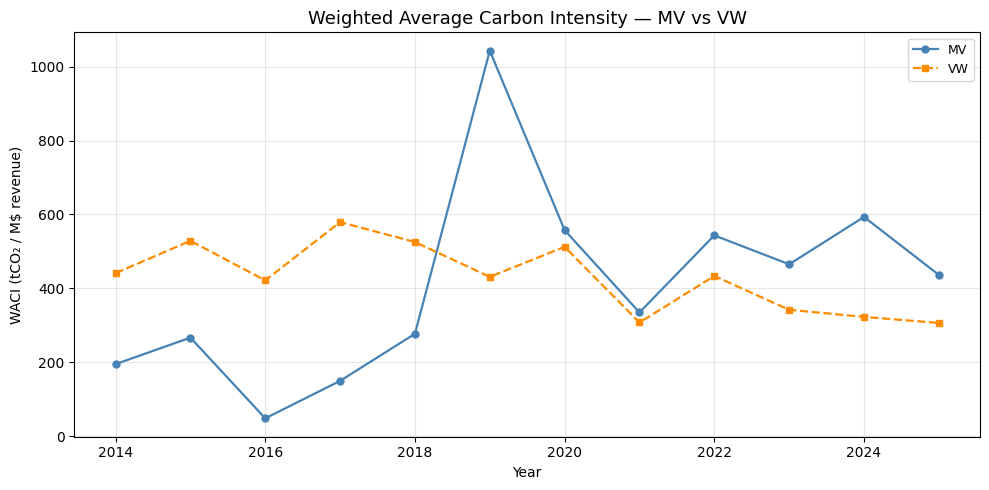

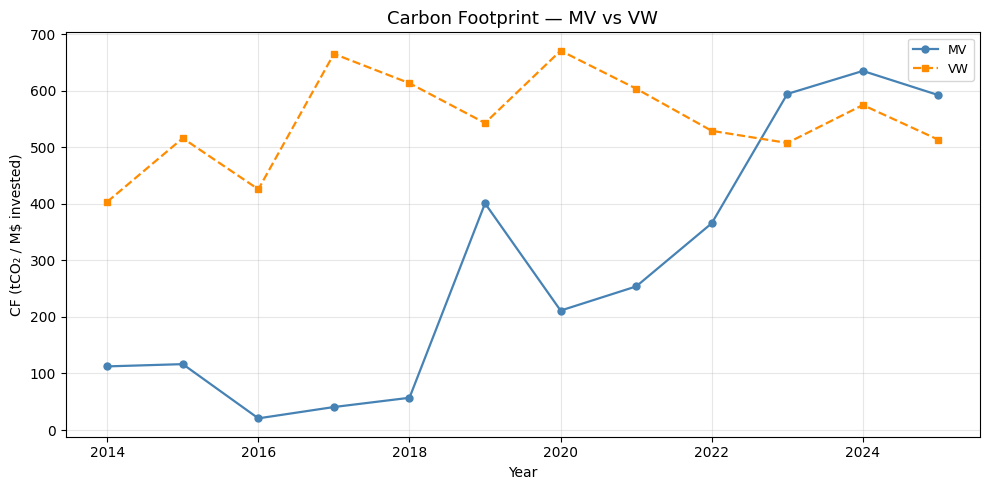

PosixPath('/workspaces/SAAM-Project/outputs/figures/cf_mv_vw.png')

In [43]:
from src.reporting_part2 import plot_carbon_metrics

plot_carbon_metrics(
    {'MV': mv_waci_series, 'VW': vw_waci_series},
    ylabel='WACI (tCO\u2082 / M$ revenue)',
    title='Weighted Average Carbon Intensity \u2014 MV vs VW',
    figures_dir=paths['FIGURES_DIR'],
    filename='waci_mv_vw.png',
    show_plot=True,
)

plot_carbon_metrics(
    {'MV': mv_cf_series, 'VW': vw_cf_series},
    ylabel='CF (tCO\u2082 / M$ invested)',
    title='Carbon Footprint \u2014 MV vs VW',
    figures_dir=paths['FIGURES_DIR'],
    filename='cf_mv_vw.png',
    show_plot=True,
)

In [44]:
# Top-10 carbon-intensive firms (last rebalance year)
last_year     = rebalance_years[-1]
last_end      = pd.Timestamp(f'{last_year - 1}-12-31')
universe_last = universe_by_year[last_year]

cf_pu_last = compute_cf_per_unit(carbon_data, annual_caps_data, universe_last, last_end)

top10 = get_top_carbon_emitters(
    weights=mv_weights_by_year[last_year],
    cf_per_unit=cf_pu_last,
    static_df=static,
    n=10,
)
print('Top 10 firms driving carbon intensity (MV portfolio, last rebalance):')
display(top10)

Top 10 firms driving carbon intensity (MV portfolio, last rebalance):


,ISIN,Weighted_CF_Contribution,Name,Weight,CF_per_unit
0,PK0053401011,172.0282,FAUJI FERTILIZER COMPANY,0.0398,4324.4409
1,PEP702101002,143.0754,ENGIE ENERGIA PERU,0.0475,3012.3566
2,CNE1000002S8,134.5707,COSCO SHIP.EN.TRSP. 'H',0.0377,3568.1110
3,PHY751061151,68.7926,SAN MIGUEL,0.0134,5146.8262
4,PHY5764J1483,46.9779,MANILA ELECTRIC,0.0317,1479.9359
5,CNE000000SJ9,8.7280,SHAI.ZHENHUA HEAVY IND. 'B',0.0179,488.0296
6,TH0450010Y08,4.7487,THAI UNION GROUP,0.0424,112.0606
7,KR7004370003,3.6749,NONGSHIM,0.0711,51.6802
8,PHY0005M1090,1.9857,ABOITIZ POWER,0.0165,120.6668
9,MYL6033OO004,1.3671,PETRONAS GAS,0.0017,816.2869


### 3.2 Long-Only Portfolio with a Carbon Footprint Objective

We construct a long-only minimum-variance portfolio whose carbon footprint is at least 50% below the carbon footprint of the unconstrained minimum-variance portfolio.

$$\min_{\alpha} \;\alpha' \Sigma \alpha$$

subject to:

$$CF^{(p)}_Y \le 0.5 \times CF^{(P_{oos}^{mv})}_Y, \qquad \alpha'\mathbf{1}=1, \qquad \alpha_i \ge 0$$

We denote this portfolio $P_{oos}^{mv}(0.5)$.

In [45]:
from src.optimization_part2 import compute_carbon_mv_weights_by_year

mv_cf_by_year = mv_cf_series.to_dict()

carbon_mv_weights = compute_carbon_mv_weights_by_year(
    returns_matrix=returns_matrix,
    universe_by_year=universe_by_year,
    mv_cf_by_year=mv_cf_by_year,
    carbon_data=carbon_data,
    annual_caps_data=annual_caps_data,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
    carbon_reduction_target=CARBON_REDUCTION_TARGET,
    covariance_by_year=covariance_by_year,
    cf_per_unit_by_year=cf_per_unit_by_year,
)

_, carbon_mv_returns = run_portfolio_backtest(returns_matrix, carbon_mv_weights, rebalance_years)
print('Section 3.2 done.')

[carbon-MV] 2014: 254 assets ...
  [carbon-MV] 2014: done.
[carbon-MV] 2015: 278 assets ...
  [carbon-MV] 2015: done.
[carbon-MV] 2016: 309 assets ...
  [carbon-MV] 2016: done.
[carbon-MV] 2017: 345 assets ...
  [carbon-MV] 2017: done.
[carbon-MV] 2018: 389 assets ...
  [carbon-MV] 2018: done.
[carbon-MV] 2019: 424 assets ...
  [carbon-MV] 2019: done.
[carbon-MV] 2020: 472 assets ...
  [carbon-MV] 2020: done.
[carbon-MV] 2021: 511 assets ...
  [carbon-MV] 2021: done.
[carbon-MV] 2022: 546 assets ...
  [carbon-MV] 2022: done.
[carbon-MV] 2023: 573 assets ...
  [carbon-MV] 2023: done.
[carbon-MV] 2024: 584 assets ...
  [carbon-MV] 2024: done.
[carbon-MV] 2025: 568 assets ...
  [carbon-MV] 2025: done.
Section 3.2 done.



Section 3.2 — Performance:


,Ann. Return,Ann. Volatility,Sharpe Ratio,Min Monthly,Max Monthly
Portfolio,,,,,
MV,0.0788,0.1081,0.7287,-0.0747,0.1367
MV (0.5),0.0733,0.1047,0.7005,-0.0723,0.1406


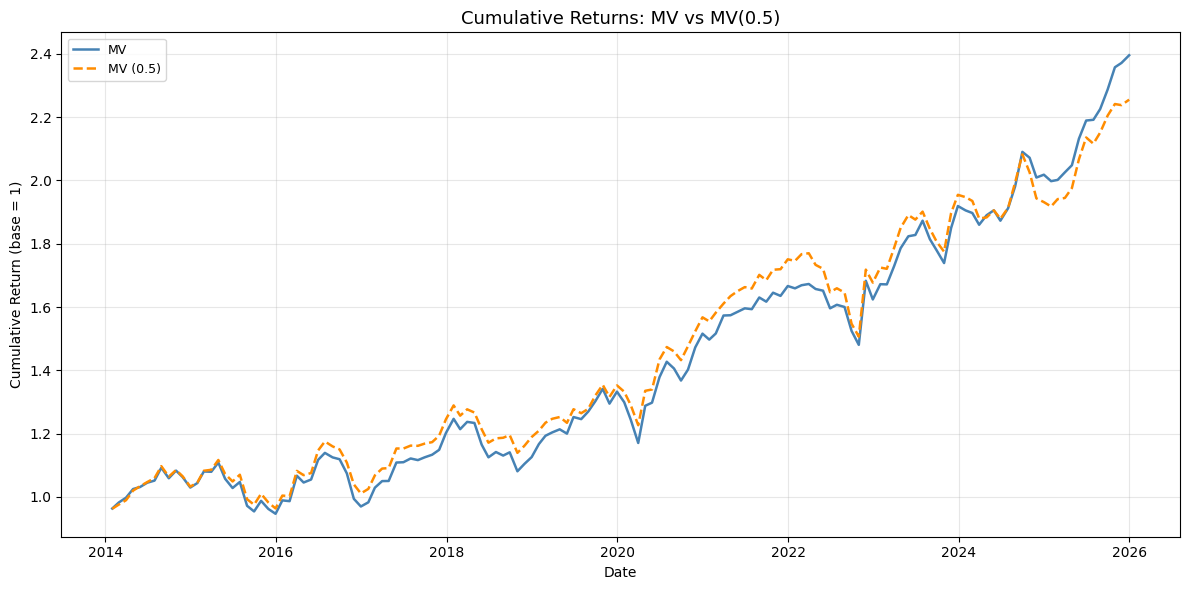

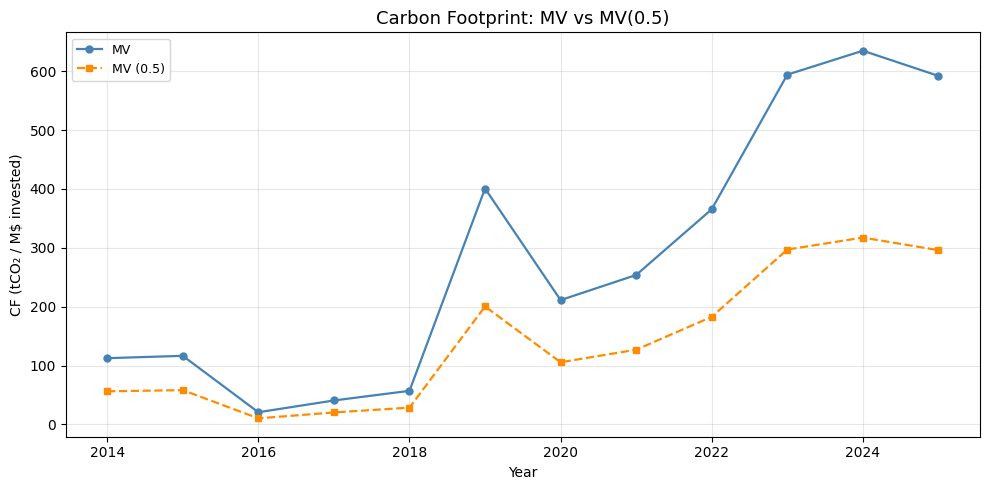

PosixPath('/workspaces/SAAM-Project/outputs/figures/cf_section32.png')

In [46]:
from src.reporting_part2 import (
    build_performance_table, compute_cumulative_returns, plot_cumulative_performance
)

cmv_waci, cmv_cf = compute_carbon_metrics_timeseries(
    carbon_mv_weights, universe_by_year, carbon_data, annual_caps_data,
    carbon_intensity, rebalance_years,
)

returns_32 = {'MV': mv_returns_oos, 'MV (0.5)': carbon_mv_returns}
print('\nSection 3.2 \u2014 Performance:')
display(build_performance_table(returns_32))

plot_cumulative_performance(
    compute_cumulative_returns(returns_32), paths['FIGURES_DIR'],
    filename='cumulative_section32.png',
    title='Cumulative Returns: MV vs MV(0.5)', show_plot=True,
)
plot_carbon_metrics(
    {'MV': mv_cf_series, 'MV (0.5)': cmv_cf},
    ylabel='CF (tCO\u2082 / M$ invested)',
    title='Carbon Footprint: MV vs MV(0.5)',
    figures_dir=paths['FIGURES_DIR'], filename='cf_section32.png', show_plot=True,
)

### 3.3 Tracking Error Minimization

We now take the point of view of a passive investor: the objective is to remain as close as possible to the value-weighted benchmark while reducing the carbon footprint by 50%.

$$\min_{\alpha} \; TE = \sqrt{(\alpha - \alpha^{vw})' \Sigma (\alpha - \alpha^{vw})}$$

subject to:

$$CF^{(p)}_Y \le 0.5 \times CF^{(P_{oos}^{vw})}_Y, \qquad \alpha'\mathbf{1}=1, \qquad \alpha_i \ge 0$$

We denote this portfolio $P_{oos}^{vw}(0.5)$.

In [ ]:
from src.optimization_part2 import compute_te_min_weights_by_year

vw_cf_by_year   = vw_cf_series.to_dict()
cf_target_50_vw = {yr: CARBON_REDUCTION_TARGET * vw_cf_by_year[yr] for yr in rebalance_years}

te_50_weights = compute_te_min_weights_by_year(
    returns_matrix=returns_matrix,
    market_caps_data=market_caps_data,
    universe_by_year=universe_by_year,
    cf_target_by_year=cf_target_50_vw,
    carbon_data=carbon_data,
    annual_caps_data=annual_caps_data,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
    covariance_by_year=covariance_by_year,
    cf_per_unit_by_year=cf_per_unit_by_year,
)

_, te_50_returns = run_portfolio_backtest(returns_matrix, te_50_weights, rebalance_years)
print('Section 3.3 done.')

[TE-min] 2014: 254 assets ...
  [TE-min] 2014: done.
[TE-min] 2015: 278 assets ...
  [TE-min] 2015: done.
[TE-min] 2016: 309 assets ...
  [TE-min] 2016: done.
[TE-min] 2017: 345 assets ...
  [TE-min] 2017: done.
[TE-min] 2018: 389 assets ...
  [TE-min] 2018: done.
[TE-min] 2019: 424 assets ...
  [TE-min] 2019: done.
[TE-min] 2020: 472 assets ...
  [TE-min] 2020: done.
[TE-min] 2021: 511 assets ...
  [TE-min] 2021: done.
[TE-min] 2022: 546 assets ...


In [ ]:
te50_waci, te50_cf = compute_carbon_metrics_timeseries(
    te_50_weights, universe_by_year, carbon_data, annual_caps_data,
    carbon_intensity, rebalance_years,
)

returns_33 = {'VW': vw_returns_oos, 'VW (0.5)': te_50_returns}
print('\nSection 3.3 \u2014 Performance:')
display(build_performance_table(returns_33))

plot_cumulative_performance(
    compute_cumulative_returns(returns_33), paths['FIGURES_DIR'],
    filename='cumulative_section33.png',
    title='Cumulative Returns: VW vs VW(0.5)', show_plot=True,
)
plot_carbon_metrics(
    {'VW': vw_cf_series, 'VW (0.5)': te50_cf},
    ylabel='CF (tCO\u2082 / M$ invested)',
    title='Carbon Footprint: VW vs VW(0.5)',
    figures_dir=paths['FIGURES_DIR'], filename='cf_section33.png', show_plot=True,
)

The comparison highlights the trade-off between decarbonization and portfolio efficiency. 
Minimum-variance portfolios prioritize total risk reduction, while tracking-error portfolios prioritize benchmark replication under climate constraints.

### 3.4 Comparison of Portfolios

We compare the financial performance and carbon outcomes of the baseline portfolios and the 50% carbon-reduction portfolios. The key trade-off is between tracking or variance efficiency and the reduction in carbon footprint.

In [ ]:
# Baseline CF^(vw) at end of Y0=2013, used as reference for all net-zero targets
base_year_date = pd.Timestamp(f'{NET_ZERO_BASE_YEAR}-12-31')      # 2013-12-31 ✓
base_universe  = universe_by_year[BACKTEST_START_YEAR]             # universe at start of 2014
vw_cf_base     = compute_vw_cf(carbon_data, annual_caps_data, base_universe, base_year_date)

print(f'VW CF baseline (end {NET_ZERO_BASE_YEAR}): {vw_cf_base:.4f} tCO₂/M$')

# CF target for each rebalance year: (1-θ)^(Y-Y0) * CF_Y0
cf_target_nz = {
    yr: (1 - NET_ZERO_REDUCTION) ** (yr - NET_ZERO_BASE_YEAR) * vw_cf_base
    for yr in rebalance_years
}
print('\nNet-zero CF targets:')
for yr, val in cf_target_nz.items():
    print(f'  {yr}: {val:.4f}')

In [ ]:
# Cumulative returns: all 4 portfolios together
all_4_returns = {
    'MV': mv_returns_oos,
    'MV (0.5)': carbon_mv_returns,
    'VW': vw_returns_oos,
    'VW (0.5)': te_50_returns,
}

# Cumulative returns: all 4 portfolios together
plot_cumulative_performance(
    compute_cumulative_returns(all_4_returns),
    figures_dir=paths['FIGURES_DIR'],
    filename='cumulative_section34.png',
    title='Cumulative Returns: MV, MV(0.5), VW, VW(0.5)',
    show_plot=True,
)


# CF over time: all 4 portfolios
plot_carbon_metrics(
    {'MV': mv_cf_series, 'MV (0.5)': cmv_cf, 'VW': vw_cf_series, 'VW (0.5)': te50_cf},
    ylabel='CF (tCO₂ / M$ invested)',
    title='Carbon Footprint: All Portfolios (Section 3.4)',
    figures_dir=paths['FIGURES_DIR'],
    filename='cf_section34.png',
    show_plot=True,
)

## 4. Portfolio Allocation with a Net Zero Objective

The final climate strategy introduces a dynamic carbon reduction path rather than a single 50% constraint.

### 4.1 Net Zero Portfolio

The portfolio carbon footprint is reduced by $\theta = 10\%$ per year from the base year $Y_0 = 2013$:

$$CF^{(p)}_Y \le (1-\theta)^{Y-Y_0+1} \times CF^{(P_{oos}^{vw})}_{Y_0}$$

We denote this portfolio $P_{oos}^{vw}(NZ)$.

In [ ]:
base_year_date = pd.Timestamp(f"{NET_ZERO_BASE_YEAR}-12-31")
base_universe  = universe_by_year[NET_ZERO_BASE_YEAR + 1]
vw_cf_base     = compute_vw_cf(carbon_data, annual_caps_data, base_universe, base_year_date)

print(f'VW CF baseline (end {NET_ZERO_BASE_YEAR}): {vw_cf_base:.4f} tCO\u2082/M$')

cf_target_nz = {
    yr: (1 - NET_ZERO_REDUCTION) ** (yr - NET_ZERO_BASE_YEAR + 1) * vw_cf_base
    for yr in rebalance_years
}
print('\nNet-zero CF targets:')
for yr, val in cf_target_nz.items():
    print(f'  {yr}: {val:.4f}')

In [ ]:
nz_weights = compute_te_min_weights_by_year(
    returns_matrix=returns_matrix,
    market_caps_data=market_caps_data,
    universe_by_year=universe_by_year,
    cf_target_by_year=cf_target_nz,
    carbon_data=carbon_data,
    annual_caps_data=annual_caps_data,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
    covariance_by_year=covariance_by_year,
    cf_per_unit_by_year=cf_per_unit_by_year,
)

_, nz_returns = run_portfolio_backtest(returns_matrix, nz_weights, rebalance_years)
print('Section 4.1 done.')

### 4.2 Comparison of Portfolios

We compare the cumulative performance of $P_{oos}^{vw}$, $P_{oos}^{vw}(0.5)$, and $P_{oos}^{vw}(NZ)$, and discuss the possible financial cost of constructing a net-zero portfolio.

In [ ]:
nz_waci, nz_cf = compute_carbon_metrics_timeseries(
    nz_weights, universe_by_year, carbon_data, annual_caps_data,
    carbon_intensity, rebalance_years,
)

returns_sec4 = {'VW': vw_returns_oos, 'VW (0.5)': te_50_returns, 'VW (NZ)': nz_returns}
print('Section 4.2 \u2014 Performance:')
display(build_performance_table(returns_sec4))

plot_cumulative_performance(
    compute_cumulative_returns(returns_sec4), paths['FIGURES_DIR'],
    filename='cumulative_section4.png',
    title='Cumulative Returns: VW, VW(0.5) and VW(NZ)', show_plot=True,
)
plot_carbon_metrics(
    {'VW': vw_cf_series, 'VW (0.5)': te50_cf, 'VW (NZ)': nz_cf},
    ylabel='CF (tCO\u2082 / M$ invested)',
    title='Carbon Footprint: VW, VW(0.5) and VW(NZ)',
    figures_dir=paths['FIGURES_DIR'], filename='cf_section4.png', show_plot=True,
)

## Part II Summary and Export

This final block gathers the performance and carbon metrics for all portfolios and exports the tables required to reproduce the report outputs.

In [ ]:
from src.reporting_part2 import build_carbon_metrics_table, export_part2_outputs

all_returns = {
    'MV':       mv_returns_oos,
    'MV (0.5)': carbon_mv_returns,
    'VW':       vw_returns_oos,
    'VW (0.5)': te_50_returns,
    'VW (NZ)':  nz_returns,
}
waci_all = {
    'MV': mv_waci_series, 'MV (0.5)': cmv_waci,
    'VW': vw_waci_series, 'VW (0.5)': te50_waci, 'VW (NZ)': nz_waci,
}
cf_all = {
    'MV': mv_cf_series, 'MV (0.5)': cmv_cf,
    'VW': vw_cf_series, 'VW (0.5)': te50_cf, 'VW (NZ)': nz_cf,
}

perf_summary   = build_performance_table(all_returns)
carbon_summary = build_carbon_metrics_table(waci_all, cf_all)

print('=== Performance Summary ===')
display(perf_summary)
print('\n=== Carbon Metrics Summary ===')
display(carbon_summary)

In [ ]:
exported = export_part2_outputs(all_returns, waci_all, cf_all, paths['TABLES_DIR'])
perf_summary.to_csv(paths['TABLES_DIR'] / 'performance_summary_part2.csv')
carbon_summary.to_csv(paths['TABLES_DIR'] / 'carbon_metrics_summary_part2.csv')

print('All outputs saved.')
for k, v in exported.items():
    print(f'  {k}: {v.name}')